## Neuro Karaoke Archive Quality Assurance ##

This notebook was made after I found a couple of songs in the "Evil & Neuro Songs(NEURO-SAMA KARAOKE COVERS ARCHIVE V2)" MEGA folder that were of lower quality than their counterparts on PB's google drive, which is the highest quality available for Neuro's and Evil's karaoke songs.

The objective of this notebook is to compare the audio content of the Mega folder songs with the ones on the google drive and determine if there is any difference between the archives, not only comparing the bitrate but whether they are bit-perfect.

### Method ###

To achieve this objective I had to compare the exact bit content of each song to their counterpart, the first and biggest challenge was to match each song with it's respective counterpart since for both folders they had very different names, the purpose of this was to avoid the 500,000 comparisons that I would have to do otherwise, each comparison taking about 1 second, it would have taken about 140 hours to compute.

My approach for matching the songs was to compare the titles with the library `thefuzz`. Since many songs have multiple versions and therefore very similar names, I decided to first match the songs by date and then by title.
 
 

In [ ]:
from pathlib import Path
import os, re
from time import perf_counter
from mutagen import File
import mutagen.id3._util
from tqdm import tqdm
from thefuzz import fuzz
from thefuzz import process
from pydub import AudioSegment
import numpy as np
import concurrent.futures
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
class Song:
    def __init__(self, path, title="", date="", match=None, verified=False, singer=""):
        self.path = path
        self.title = title
        self.date = date
        self.match = match
        self.verified = verified
        self.singer = singer
        
    def __str__(self):
       return f"{self.title if self.title else self.path} --- {self.match.title if self.match is not None else ""}"
    def __repr__(self):
        return f"{self.title if self.title else self.path}"

In [ ]:
Mega_folder = r"path\to\Mega_Folder"
Drive_folder = r"path\to\Drive_Folder"

def get_all_mp3(directory):
    """
    Function to get all mp3 files from the folders.
    Although there were some mp4 and wav files in the drive
    only the mp3s were the target of my enquire.
    """
    p = Path(directory)
    return [Song(str(f)) for f in p.rglob('*.mp3') if f.is_file()]

Mega_files = get_all_mp3(Mega_folder)
Drive_files = get_all_mp3(Drive_folder)

In [ ]:
print(len(Mega_files))
print(len(Drive_files))

### Dates ###

Another problem that I had to account for was very inconsistent date formats.

MEGA folder songs followed MM/DD/YY in their metadata but the titles were in DD/MM/YY.

The drive mixes MM/DD/YY with DD/MM/YY. DD/MM/YY for everything but the "v1 voice" folder.


In [ ]:
def MMDDYY_to_DDMMYY(date):
    try:
        mm, dd, yy = date.split('/')
    except ValueError as e:
        return date
    if len(dd) == 1:
        dd = "0"+dd
    if len(mm) == 1:
        mm = "0"+mm
    if len(yy) == 4:
        yy = yy[-2:]
    date = "/".join([dd,mm,yy])
    return date

In [ ]:
date_pattern = r"(\(\d{2}\s\d{2}\s\d{2}\))"
v1_date_pattern = r"^(\[\d{2}-\d{2}-\d{2}\])"
singer_pattern = r"\(([NnEeDd]\w{3,4}).*?\)"
v1_gibberish = r"\[\d+\]"

Drive_dict = {}

def clean_date(date):
    removes = ['(', ')' ,'[', ']']
    replaces = ['-', ' ', '.']
    for x in removes:
        date = date.replace(x, "")
    for x in replaces:
        date = date.replace(x,"/")
    return date
    
for song in Drive_files:

    song.title = os.path.basename(song.path)
    file = song.title
    parent = os.path.basename(os.path.dirname(song.path))        
    extracted_date = ""
    
    if parent == "v1 voice":
        match = re.search(v1_date_pattern, file)
        file = re.sub(v1_gibberish, "", file)
    else:
        match = re.search(date_pattern, file)

    if match:
        extracted_date = match.group(1)
        sanitized_date = extracted_date
        sanitized_date = clean_date(sanitized_date)
            
        if parent == "v1 voice":
            sanitized_date = MMDDYY_to_DDMMYY(sanitized_date)

    singer  = re.search(singer_pattern, file)
    if singer is not None:
        singer = singer.group(1)
    else:
        singer = "Neuro"
    singer = singer.capitalize()
    
    file = file.replace(extracted_date, "").replace(".mp3", "")
    file = re.sub(singer_pattern,"",file)
    file = file.strip()

    song.title = file
    song.date = sanitized_date if match else extracted_date
    song.singer = singer

    Drive_dict.setdefault(song.date, []).append(song)

In [ ]:
Mega_dict = {}

mega_comment_sanitization = r'[\D]*$'
track_number_pattern = r'^\d+\.\s*'

def get_tag_value(tags, tag):
    frame = tags.get(tag)
    if frame is not None:
        return getattr(frame, 'text', None)


def get_date(tags):
    comment_txt = ""
    comment_value = get_tag_value(tags, 'COMM::eng')
    if not comment_value:
        comment_value = get_tag_value(tags, 'COMM::XXX')
    if comment_value is not None:
        comment_txt = str(comment_value[0])

    return comment_txt


def get_singer(tags):
    singer_text = ""
    singer_value = get_tag_value(tags, 'TPE1')
    if not singer_value:
        singer_value = get_tag_value(tags, 'TPE2')
    if singer_value:
        singer_text = str(singer_value[0])
        
    return singer_text
        

def get_comment_safe(path):
    tags = File(path)
    
    date = get_date(tags)
    singer = get_singer(tags)
    
    return singer, date


def identify_singer(text):
    singer = None
    if "duet" in text.lower():
        singer = "Duet"
    elif "evil" in text.lower():
        singer = "Evil"
    else:
        singer = "Neuro"
        
    return singer


def get_song_data(song, dictionary):
    path = song.path
    file = os.path.basename(path)

    singer  = re.search(singer_pattern, file)
    if singer is not None:
        singer = singer.group(1)
        
    date = re.search(date_pattern, file)
    if date is not None:    
        date = date.group(1)
    
    if (not singer) or (not date):
        singer_meta, date_meta = get_comment_safe(path)
    if not singer:
        singer = singer_meta
    meta = False
    if not date:
        date = date_meta
        meta = True
        
    sanitized_date = re.sub(mega_comment_sanitization, "", date)
    sanitized_date = clean_date(sanitized_date)
    sanitized_date = MMDDYY_to_DDMMYY(sanitized_date) if meta else sanitized_date

    file = re.sub(date_pattern, '', file)
    file = re.sub(track_number_pattern, '', file)
    file = re.sub(singer_pattern, '', file)
    file = file.replace(".mp3", "")
    file_sanitized = file.strip()
    
    song.title = file_sanitized
    song.date = sanitized_date
    song.singer = identify_singer(singer)
    
    dictionary.setdefault(sanitized_date, []).append(song)

if __name__ == "__main__":
    for song in tqdm(Mega_files):
        get_song_data(song, Mega_dict)

In [ ]:
neuro_songs = 0
evil_songs = 0
duet_songs = 0
for key in Mega_dict:
    for song in Mega_dict[key]:
        if song.singer == "Evil":
            evil_songs+=1
        elif song.singer == "Duet":
            duet_songs += 1
        elif song.singer == "Neuro":
            neuro_songs += 1
print(neuro_songs)
print(evil_songs)
print(duet_songs)

In [ ]:
def find_song(full_title, D):
    for key in D:
        for song in D[key]:
            song_full_title = os.path.basename(song.path)
            if song_full_title == full_title:
                return song
    print("Error:", full_title)
    return None

### Manual Fixes ###

Despite trying to automate as much as possible I still felt the need to include a manual matching list for songs that the code was unable or at least very unwilling to correctly match.

In [ ]:
mega = ["52. I'm Gonna Be (500 Miles) (Duet.v3).mp3", "93. Fluorite Eye's Song.mp3",
        "Ensemble For Polaris - Vivy Fluorite Eye_s Song (s.mp3", "Kyoufuu All Back - Yukopi (25 10 23).mp3", 
        "1. Anniversary Mashup (2023).mp3", "2. Anniversary Mashup (2024).mp3", 
        "3. 4 00 A.M. (Evil.v1).mp3", "69. It's Been So Long.mp3",
        "96. Sis x Love (Duet.v3).mp3", "13. KARMANATIONS.mp3",
       "26. Guitar, Loneliness, and Blue Planet.mp3", "25. A Thousand Years.mp3"]
drive = ["The Proclaimers - I'm Gonna Be (500 Miles) (19 03 25).mp3", "[05／17／23] fluorites eye's song.mp3",
         "Ensemble For Polaris - Vivy Fluorite Eye's Song (s.mp3", "Kyoufuu All Back - Yukopi (25 10 23).mp3", 
         "neuro anniversary mashup.mp3", "neuro anniversary mashup year 2.mp3", 
         "Taeko Ohnuki - 4 00 A.M. (evil) (28 05 25).mp3", "fnaf.mp3", 
         "HoneyWorks - SisxLove (06 08 25).mp3", "karmanations.mp3",
        "guitar loneliness and blue planet.mp3", "a thousand years.mp3"]

for y, x in enumerate(mega):
    song1 = find_song(x, Mega_dict)
    if song1 and song1.verified == True:
        continue
        
    song2 = find_song(drive[y], Drive_dict)
    if song1 and song2:
        song1.match = song2
        song2.match = song1                

In [ ]:
def Match(song_obj, song_obj_list, cut_off):
    """
    The function responsible for matching the songs.
    I tested multiple fuzz matching scorers with varying
    levels of success and ended up using partial_ratio.
    """
    song = song_obj.title
    song_list = [song.title if (song.match is None) else "" for song in song_obj_list]    
    
    pick = process.extractOne(song, song_list, scorer=fuzz.partial_ratio, score_cutoff=cut_off)
            
    if pick != None:
        song_index = song_list.index(pick[0])
        song_obj.match = song_obj_list[song_index]
        song_obj_list[song_index].match = song_obj
    return

In [ ]:
for date_key in Mega_dict:
    mega_songs, drive_songs = Mega_dict.get(date_key), Drive_dict.get(date_key)
    if mega_songs and drive_songs:
        for song in mega_songs:
            if song.match is None:
                Match(song, drive_songs, 100) # Cut-off value, it's nice to keep around 100 methinks

In [ ]:
mega_songs = []
drive_songs = []

for key in Mega_dict:
    for song in Mega_dict[key]:
        if (song.verified == False) and (song.match is None):
            mega_songs.append(song)

for key in Drive_dict:
    for song in Drive_dict[key]:
        if (song.verified == False) and (song.match is None):
            drive_songs.append(song)
        
for song in mega_songs: 
    if song.match is None:
        Match(song, drive_songs, 90) # Cut-off value
        if song.match is not None:
            drive_songs.remove(song.match)

### Recreating the Data ###

Since the matching is flawed, it is bound to make incorrect matches, the function below was made to undo the mistakes without losing progress.
For recreating the data, I recommend keeping the cut-off score of the first matching block high, but progressively decreasing the cut-off of the block above as needed.

In [ ]:
def Disassociate(Dict):
    for key in Dict:
        for song in Dict[key]:
            if song.verified == False:
                song.match = None

Disassociate(Mega_dict)
Disassociate(Drive_dict)

In [ ]:
def compare_mp3(song):
    
    file1 = song.path
    file2 = song.match.path
    audio1 = AudioSegment.from_mp3(file1)
    audio2 = AudioSegment.from_mp3(file2)

    # Convert to raw audio data (PCM)
    raw_audio1 = np.array(audio1.get_array_of_samples())
    raw_audio2 = np.array(audio2.get_array_of_samples())

    if (raw_audio1.shape != raw_audio2.shape) or (np.array_equal(raw_audio1, raw_audio2) == False):
        #print(f"{song.date}:\n{song.title} is different from {song.match.title}")
        return False
        
    song.verified = True
    song.match.verified = True
    
    return True

### Verifying the Matches ###

The code below is pretty slow, it takes about 1 second for each comparison, with about 1200 songs total it takes
about 20 minutes to finish.

In [ ]:
if __name__ == "__main__": #This takes just about 20 minutes to complete
    start = perf_counter()
    with concurrent.futures.ThreadPoolExecutor() as executor:   
        futures = []
        for key in list(Mega_dict)[:]:
            for song in Mega_dict[key]:
                if (song.match is not None) and (song.verified == False):
                    future = executor.submit(compare_mp3, song)
                    futures.append(future)
    for future in concurrent.futures.as_completed(futures):
        result = future.result()         
    end = perf_counter()
    print(f"Runtime: {round((end-start),2)} secs")

In [ ]:
failed_matches = 0 # Fuzz matching failiure
failed_verification = 0 # Fuzz matching failiure and database failiure
for key in Drive_dict:
    for song in Drive_dict[key]:
        if song.match is None:
            failed_matches +=1
        elif song.verified == False:
            failed_verification+=1       
print(f"Fail matches rate: {round(failed_matches/len(Drive_files)*100, 2)}%")
print(f"Failed verification rate: {round(failed_verification/len(Drive_files)*100,2)}%")

In [ ]:
"""
prints for debugging.
any blank file from the drive is
likely a mistake since there are 
about 20 more songs on the MEGA folder

the print statements were designed in a
way to make it easy check for mistakes 
manually with the code block below.
"""
for key in Mega_dict:
    for song in Mega_dict[key]:
        if (song.verified == False) and (song.match is not None):
            print(f"""{song.match.date}\nfile1= r"{song.path}"\nfile2= r"{song.match.path}" """)
        elif song.match is None:
            print(f"""\nBLANK:\nfile1= r"{song.path}"\n""")
for key in Drive_dict:
    for song in Drive_dict[key]:
        if (song.verified == False) and song.match is None:
            print(f"""\nBLANK:\nfile2= r"{song.path}"\n""")

In [ ]:
def manual_compare(file1, file2):
    audio1 = AudioSegment.from_mp3(file1)
    audio2 = AudioSegment.from_mp3(file2)
    start = perf_counter()

    raw_audio1 = np.array(audio1.get_array_of_samples())
    raw_audio2 = np.array(audio2.get_array_of_samples())

    if raw_audio1.shape != raw_audio2.shape:
        return False

    return np.array_equal(raw_audio1, raw_audio2)

file1= r"path\to\file1"
file2= r"path\to\file2" 

if manual_compare(file1, file2):
    print("The MP3 files are bit-perfect.")
else:
    print("The MP3 files are different.")

In [ ]:
blanks = []

def parent_file(song):
    parent = os.path.basename(os.path.dirname(song.path))
    file = os.path.basename(song.path)
    return parent+'/'+file

with open('Compressed_songs.txt', 'w+', encoding='utf-8') as handle:
    for key in Mega_dict:
        for song in Mega_dict[key]:
            if song.verified == False:
                if song.match is None:
                    blanks.append(song)
                else:
                    handle.write(parent_file(song)+"\n")

    handle.write("\nBLANKS:\n")
    for song in blanks:
        handle.write(parent_file(song)+"\n")

In [ ]:
def create_spreadsheet_data(mega_dict):
    """
    Extracts data from the Song objects into a spreadsheet.
    """
    
    records = []
    
    for key, song_list in mega_dict.items():
        for song in song_list:
            record = {
                    'Mega Path': song.path,
                    'Mega Title': song.title,
                    'Mega Date': song.date
                    }
            if song.match is not None:
                record.update({  
                    'Drive Path': song.match.path,
                    'Drive Title': song.match.title,
                    'Drive Date': song.match.date
                    })
            
            records.append(record)
                
    return records

data_records = create_spreadsheet_data(Mega_dict)

df = pd.DataFrame(data_records)

df.to_excel('song_comparison_report.xlsx', index=False) 
print("Spreadsheet 'song_comparison_report.xlsx' created successfully.")

### Graphic ###

Having the data already complete I thought it would be fun to make a graphic to visualize the songs.

In [ ]:
neuros = {}
evils = {}
twins = {}
for date, value in Mega_dict.items():
    neuro_count = 0
    evil_count = 0
    duet_count = 0
    for song in value:
        if song.singer == "Evil":
            evil_count+=1
        elif song.singer == "Duet":
            duet_count += 1
        else:
            neuro_count += 1
    neuros.setdefault(date, neuro_count)
    evils.setdefault(date, evil_count)
    twins.setdefault(date, duet_count)

In [ ]:
neuro_series = pd.Series(neuros)
evil_series = pd.Series(evils)
duet_series = pd.Series(twins)

neuro_series.index = pd.to_datetime(neuro_series.index, format='%d/%m/%y')
evil_series.index = pd.to_datetime(evil_series.index, format='%d/%m/%y')
duet_series.index = pd.to_datetime(duet_series.index, format='%d/%m/%y')

neuro_series = neuro_series.sort_index()
evil_series = evil_series.sort_index()
duet_series = duet_series.sort_index()

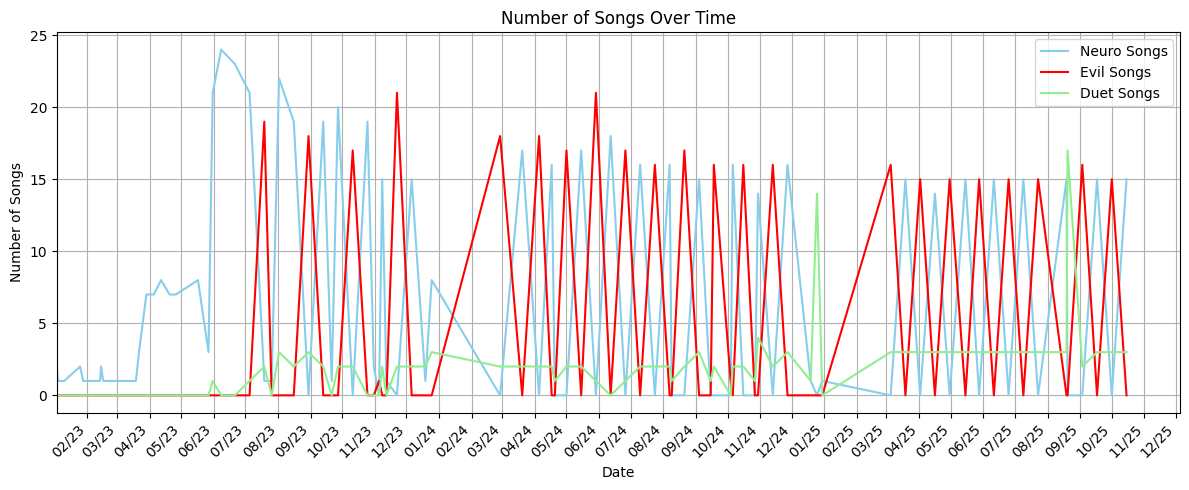

In [103]:
plt.figure(figsize=(12, 5)) 

neuro_series.plot(
    kind='line',
    linestyle='-',
    color='skyblue'
)
evil_series.plot(
    kind='line',
    linestyle='-',
    color='red'
)
duet_series.plot(
    kind='line',
    linestyle='-',
    color='lightgreen'
)

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%y')) 

plt.xlim(neuro_series.index.min(), None)

plt.title('Number of Songs Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Songs')
plt.grid(True)
plt.legend(['Neuro Songs', 'Evil Songs', 'Duet Songs'])

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Graph Analysis ###

The graph shows a very stable trend of songs, with the blue and red spikes representing Neuro and Evil karaoke streams, respectively.

The huge red spikes represent a 3-month-long break after the subathons, which was immediately followed by an Evil karaoke stream.